## Run a quantum simulation and plot q-variance and the q-distribution

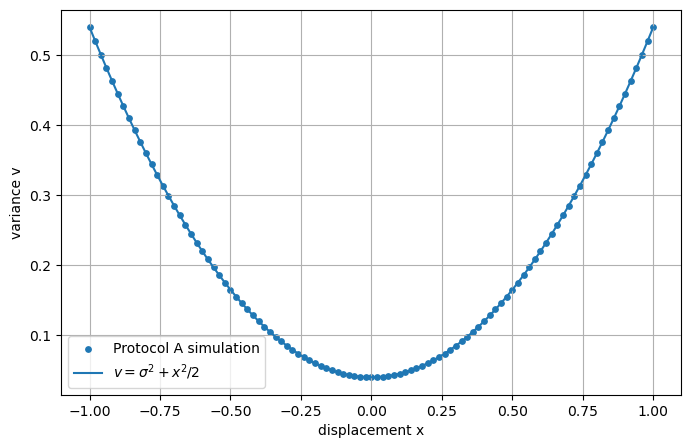

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

from scipy.stats import poisson, norm
from math import factorial

# -----------------------------------------
# Parameters
# -----------------------------------------

N = 50              # oscillator Hilbert dimension
sigma = 0.2         # ground-state volatility

x_values = np.linspace(-1,1,101)

# -----------------------------------------
# Collective oscillator operators
# -----------------------------------------

a = destroy(N)
adag = a.dag()

number = adag*a

# dimensionless Hamiltonian
H = number + 0.5*qeye(N)


# -----------------------------------------
# Ground state (lambda=0)
# -----------------------------------------

psi0 = basis(N,0)


# -----------------------------------------
# Displace and infer variance
# -----------------------------------------

variance = []

for x in x_values:

    # displacement corresponding to physical x
    alpha = x/(np.sqrt(2)*sigma)

    D = displace(N, alpha)

    psi = D*psi0

    # occupation number after displacement
    nbar = expect(number, psi)

    # q-variance
    v = sigma**2*(1+nbar)

    variance.append(v)


# -----------------------------------------
# Plot
# -----------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(
    x_values,
    variance,
    s=15,
    label="Protocol A simulation"
)

plt.plot(
    x_values,
    sigma**2 + x_values**2/2,
    label=r"$v=\sigma^2+x^2/2$"
)

plt.xlabel("displacement x")
plt.ylabel("variance v")
plt.legend()
plt.grid()


plt.show()


## Now plot the q-distribution

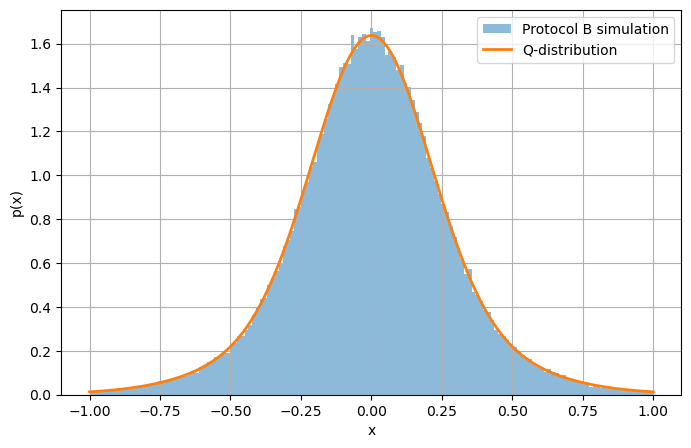

In [5]:
# -----------------------------------------
# Parameters
# -----------------------------------------

lam = 0.5           # Poisson parameter

samples = 200000    # Monte Carlo repetitions


# -----------------------------------------
# Harmonic oscillator operators
# -----------------------------------------

a = destroy(N)
number = a.dag()*a


# -----------------------------------------
# Construct Poisson-weighted state
# -----------------------------------------

w = np.zeros(N)

for n in range(N):
    w[n] = np.exp(-lam)*lam**n/factorial(n)

# normalize because of cutoff
w /= np.sum(w)

psi = sum(
    np.sqrt(w[n])*basis(N,n)
    for n in range(N)
)


# -----------------------------------------
# Protocol B:
# measure energy N, then measure x
# -----------------------------------------

# probabilities of energy measurement
energy_prob = np.array([
    expect(basis(N,n)*basis(N,n).dag(), psi)
    for n in range(N)
])


x_samples = []

for i in range(samples):

    # ---- energy measurement ----
    n = np.random.choice(
        np.arange(N),
        p=energy_prob
    )

    # collapse to |n>
    state_n = basis(N,n)


    # ---- position measurement ----

    # oscillator quadrature
    X = (a+a.dag())/np.sqrt(2)

    # numerical quadrature sampling:
    # Fock state has Gaussian envelope with variance n+1/2
    x_std = sigma*np.sqrt(2*n+1)

    x = np.random.normal(
        loc=0,
        scale=x_std
    )

    x_samples.append(x)


x_samples = np.array(x_samples)



# -----------------------------------------
# Plot simulated distribution
# -----------------------------------------

plt.figure(figsize=(8,5))

bins = np.linspace(
    -1,
    1,
    150
)

plt.hist(
    x_samples,
    bins=bins,
    density=True,
    alpha=0.5,
    label="Protocol B simulation"
)

# -----------------------------------------
# Theoretical q-distribution
# -----------------------------------------

x_grid = np.linspace(-1,1,500)

p = np.zeros_like(x_grid)

for n in range(N):

    sigma_n = sigma*np.sqrt(2*n+1)

    p += (
        w[n]
        *
        norm.pdf(
            x_grid,
            0,
            sigma_n
        )
    )


plt.plot(
    x_grid,
    p,
    linewidth=2,
    label="Q-distribution"
)


plt.xlabel("x")
plt.ylabel("p(x)")
plt.legend()
plt.grid()

plt.show()